**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 4**
Exploración de datos

---

*   NOMBRE: Ricardo Martin Galvan Paez
*   MATRÍCULA: A01253169

En esta actividad trabajarás con el archivo `personal_loan.csv`, basado en un conjunto de datos sobre clientes bancarios y su comportamiento financiero disponible en Kaggle.

Los datos fueron recopilados para analizar la posibilidad de que los clientes acepten un préstamo personal y contienen información demográfica, financiera y de productos bancarios asociados. Los indicadores incluidos son:

* `ID`: Identificador único del cliente
* `Age`: Edad del cliente (años completos)
* `Experience`: Experiencia laboral en años
* `Income`: Ingreso anual del cliente (en miles de dólares. Por ejemplo, 60 = 60,000 USD/año)
* `ZIP Code`: Código postal del cliente
* `Family`: Número de miembros de la familia
* `CCAvg`: Promedio de gastos mensuales con tarjeta de crédito (en miles de dólares)
* `Education`: Nivel educativo (1 = graduado, 2 = universitario, 3 = posgrado)
* `Mortgage`: Monto de hipoteca que posee el cliente (en miles de dólares)
* `Securities Account`: Indicador de si tiene cuenta de valores (1 = sí, 0 = no)
* `CD Account`: Indicador de si tiene cuenta de certificado de depósito (1 = sí, 0 = no)
* `Online`: Indicador de si usa los servicios bancarios en línea (1 = sí, 0 = no)
* `CreditCard`: Indicador de si es titular de tarjeta de crédito (1 = sí, 0 = no)
* `Personal Loan`: Si el cliente aceptó (1) o no (0) un préstamo personal. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [ ]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

1. Descarga el archivo: `personal_loan.csv` y guarda, en un dataframe (`loan_df`), todos sus registros.
* Haz que la columna `ID` sea el índice del dataframe.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Se observa que el conjunto de datos cuenta con 8 columnas numéricas, de las cuales 6 son de tipo entero int y 2 de tipo decimal float, además de 5 columnas de texto.

In [ ]:
loan_df = pd.read_csv('/content/drive/MyDrive/Posgrado/1er trimestre/TC5053.10_Ciencia y analítica de datos/Colab/Actividad4EDA/personal_loan.csv')
loan_df.set_index('ID', inplace=True)
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5037 entries, 0 to 5036
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5037 non-null   int64  
 1   Experience          5037 non-null   int64  
 2   Income              5037 non-null   int64  
 3   ZIP Code            5037 non-null   int64  
 4   Family              5037 non-null   int64  
 5   CCAvg               5037 non-null   float64
 6   Education           5037 non-null   float64
 7   Mortgage            5037 non-null   int64  
 8   Personal Loan       5037 non-null   object 
 9   Securities Account  5037 non-null   object 
 10  CD Account          5037 non-null   object 
 11  Online              5037 non-null   object 
 12  CreditCard          5037 non-null   object 
dtypes: float64(2), int64(6), object(5)
memory usage: 550.9+ KB


Con base en esta descripción, se considera necesario convertir las columnas Zip Code y Education al tipo object, dado que representan datos cualitativos, nominal y ordinal respectivamente.

# Limpieza

2. Obtén las estadísticas descriptivas de las variables numéricas y examina cuidadosamente los valores obtenidos de cada columna.
* Filtra el dataframe para visualizar los registros en que la edad supera los 100 años y elimínalos si no son pausibles.
* Analiza el resto de las variables y elimina aquellos registros que contengan valores inválidos o inconsistentes. Para cada acción que realices, justifica la decisión, explicando por qué consideras que el valor es incorrecto.
* ¿Cuántos registros se eliminaron (considerando todas las acciones de este ejercicio) y qué porcentaje representa respecto al total del dataframe inicial?

In [ ]:
loan_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5037.0,45.411356,11.646805,23.0,35.0,45.0,55.0,144.0
Experience,5037.0,20.122494,11.461278,-3.0,10.0,20.0,30.0,43.0
Income,5037.0,73.898352,46.130504,8.0,39.0,64.0,98.0,224.0
ZIP Code,5037.0,93152.865595,2119.637960,9307.0,91911.0,93437.0,94608.0,96651.0
Family,5037.0,2.394679,1.151145,-3.0,1.0,2.0,3.0,4.0
CCAvg,5037.0,1.942404,1.755954,0.0,0.7,1.5,2.6,10.0
Education,5037.0,1.880941,0.843337,1.0,1.0,2.0,3.0,7.3
Mortgage,5037.0,56.500695,101.657580,0.0,0.0,0.0,101.0,635.0


In [ ]:
loan_df[loan_df['Age'] > 100]

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
10,123,39,105,94710,4,2.4,3.0,0,0,0,0,No,0
250,144,6,29,94305,3,1.0,2.0,117,0,No,0,No,No
4800,130,7,73,94028,1,2.5,1.0,135,0,No,0,0,0


Dado que únicamente representan 3 registros de un total de 5,037, pueden eliminarse sin inconveniente, ya que corresponden a personas con una edad fuera del rango normal. Asimismo, se eliminaron los registros con valores negativos en las columnas Experience y Family.

In [ ]:
# Porcentaje que representa del total
len(loan_df[loan_df['Age'] > 100]) / len(loan_df) * 100

0.05955926146515784

In [ ]:
loan_df.drop(loan_df[loan_df['Age'] > 100].index, inplace=True)

In [ ]:
# Porcentaje que representa del total
len(loan_df[loan_df['Experience'] < 0]) / len(loan_df) * 100

1.0528406833531982

In [ ]:
loan_df.drop(loan_df[loan_df['Experience'] < 0].index, inplace=True)

In [ ]:
# Porcentaje que representa del total
len(loan_df[loan_df['Family'] < 0]) / len(loan_df) * 100

0.04015257980325236

In [ ]:
loan_df.drop(loan_df[loan_df['Family'] < 0].index, inplace=True)

In [ ]:
loan_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,4979.0,45.579434,11.308712,24.0,36.0,46.0,55.0,67.0
Experience,4979.0,20.352882,11.301033,0.0,11.0,20.0,30.0,43.0
Income,4979.0,73.940149,46.205921,8.0,39.0,64.0,98.0,224.0
ZIP Code,4979.0,93150.585861,2125.175857,9307.0,91910.5,93437.0,94608.0,96651.0
Family,4979.0,2.391243,1.148641,1.0,1.0,2.0,3.0,4.0
CCAvg,4979.0,1.940382,1.756574,0.0,0.7,1.5,2.6,10.0
Education,4979.0,1.878349,0.843214,1.0,1.0,2.0,3.0,7.3
Mortgage,4979.0,56.652942,101.810288,0.0,0.0,0.0,101.0,635.0


En total, se eliminaron 58 registros, lo que representa el 1.15% del conjunto de datos.

3. Obtén las estadísticas descriptivas de las variables de texto e imprime las frecuencias de sus categorías.
* Algunas columnas almacenan valores binarios utilizando distintos formatos. Unifica estos valores de manera consistente, asegurándote de que coincidan con la descripción de las variables al inicio de esta libreta.

In [ ]:
loan_df.describe(include='object').T

,count,unique,top,freq
Personal Loan,4979,4,0,3476
Securities Account,4979,4,No,2693
CD Account,4979,4,No,2462
Online,4979,4,Yes,1700
CreditCard,4979,4,0,2628


In [ ]:
loan_df['Personal Loan'].unique()

array(['0', 'No', 'Yes', '1'], dtype=object)

In [ ]:
columnas = ['Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']
for col in columnas:
    loan_df[col] = loan_df[col].replace({'1': 'Yes', '0': 'No'})


In [ ]:
loan_df.describe(include='object').T

,count,unique,top,freq
Personal Loan,4979,2,No,4494
Securities Account,4979,2,No,4459
CD Account,4979,2,No,4675
Online,4979,2,Yes,2977
CreditCard,4979,2,No,3513


4. Verifica si hay registros duplicados y si fuera así, elimínalos del dataframe.
* Asegúrate de reiniciar el índice para mantener una secuencia continua tras todas las eliminaciones de registros que hasta este punto se han realizado.

Se identificaron 36 registros duplicados en el conjunto de datos.

In [ ]:
loan_df.duplicated().sum()

np.int64(36)

In [ ]:
loan_df[loan_df.duplicated()]

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
5000,47,21,42,95841,4,0.1,1.0,0,No,No,No,Yes,Yes
5001,64,40,169,91320,2,2.1,1.0,122,No,No,No,Yes,No
5002,44,18,68,93943,4,2.9,1.0,0,No,Yes,No,No,No
5004,63,39,49,90275,1,0.8,1.0,103,No,No,No,Yes,No
5005,35,11,24,95521,4,0.4,2.0,0,No,No,No,No,No
5006,53,28,14,94005,4,0.8,1.0,0,No,No,No,Yes,Yes
5007,37,13,79,91330,1,3.6,2.0,104,No,No,No,Yes,No
5008,45,21,91,95054,1,4.7,1.0,0,No,No,No,Yes,No
5009,51,25,175,90089,3,0.7,1.0,312,Yes,No,No,No,No


In [ ]:
loan_df.drop_duplicates(inplace=True)
loan_df.reset_index(drop=True, inplace=True)
loan_df

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91108,4,1.6,1.0,0,No,Yes,No,No,No
1,45,19,34,90089,3,1.5,1.0,0,No,Yes,No,No,No
2,39,15,11,94720,1,1.0,1.0,0,No,No,No,No,No
3,35,9,100,94112,1,2.7,2.0,0,No,No,No,No,No
4,35,8,45,91330,4,1.0,2.0,0,No,No,No,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4938,29,3,40,92697,1,1.9,3.0,0,No,No,No,Yes,No
4939,30,4,15,92037,4,0.4,1.0,85,No,No,No,Yes,No
4940,63,39,24,93023,2,0.3,3.0,0,No,No,No,No,No
4941,65,40,49,90034,3,0.5,2.0,0,No,No,No,Yes,No


Por último, se verifica que los registros duplicados hayan sido eliminados correctamente.

In [ ]:
loan_df[loan_df.duplicated()]

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard


5. Aunque hasta ahora se han considerado los tipos de datos inferidos por pandas, antes del EDA es recomendable revisar la naturaleza estadística de cada variable (continua, discreta, categórica, binaria, etc.) para aplicar el análisis adecuado.

* Efectúa las siguientes conversiones:
  - Nominal: ZIP Code - `object`
  - Ordinal: Education - `category` con orden 1, 2, 3
  - Binarias: Personal Loan, Securities Account, CD Account, Online, CreditCard - `category`
* Crea dos listas llamadas `num_cols` y `cat_cols` que contengan los nombres de las variables numéricas (int64, float64) y categóricas (object, category) del dataset, respectivamente.

In [ ]:
loan_df['ZIP Code'] = loan_df['ZIP Code'].astype('object')
loan_df['Education'] = loan_df['Education'].astype('category').cat.set_categories([1, 2, 3], ordered=True)
columnas = ['Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']
for col in columnas:
    loan_df[col] = loan_df[col].astype('category')

In [ ]:
num_cols = loan_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = loan_df.select_dtypes(include=['object', 'category']).columns.tolist()

Se confirma que las variables fueron asignadas correctamente a su respectiva categoría.

In [ ]:
num_cols

['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Mortgage']

In [ ]:
cat_cols

['ZIP Code',
 'Education',
 'Personal Loan',
 'Securities Account',
 'CD Account',
 'Online',
 'CreditCard']

6. Para el análisis de las variables numéricas obtén nuevamente las estadísticas descriptivas incluyendo los valores de simetría y curtosis.
* Clasifica las variables `Age`, `Income` y `Mortgage` según los valores observados de asimetría y curtosis.




---


*   Age: presenta una distribución aproximadamente simétrica, con un valor de sesgo dentro del rango aceptable de +-0.5, lo que indica que los datos de edad están distribuidos simétricamente. La curtosis de -1.16 señala una distribución platicúrtica, es decir, achatada, lo que sugiere que los valores están muy dispersos.
*   Income: cuenta con un sesgo de 0.84, lo que indica que sea ligera asimétria con cola hacia la derecha (positiva). La curtosis de -0.04 la clasifica como aproximadamente mesocúrtica, por lo que la distribución de los datos es cercana a la normal.

*    Mortgage: presenta un sesgo de 2.1, lo que refleja que sea asimetría con cola hacia la derecha (positiva). La curtosis de 4.76 la clasifica como leptocúrtica o picuda, lo que indica que los datos están muy concentrados en un punto.


In [ ]:
stats = loan_df[num_cols].describe().T
stats['skew'] = loan_df[num_cols].skew()
stats['kurtosis'] = loan_df[num_cols].kurtosis()
stats

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Age,4943.0,45.557152,11.317371,24.0,36.0,46.0,55.0,67.0,-0.023114,-1.161292
Experience,4943.0,20.332187,11.309957,0.0,11.0,20.0,30.0,43.0,-0.015524,-1.134567
Income,4943.0,73.809630,46.105644,8.0,39.0,64.0,98.0,224.0,0.842448,-0.045446
Family,4943.0,2.391867,1.148253,1.0,1.0,2.0,3.0,4.0,0.159299,-1.403894
CCAvg,4943.0,1.935517,1.748162,0.0,0.7,1.5,2.6,10.0,1.595181,2.637713
Mortgage,4943.0,56.640704,101.861109,0.0,0.0,0.0,101.0,635.0,2.104501,4.763152


7. Genera un histograma para cada variable numérica, incluyendo la curva KDE y la curva de una distribución normal como referencia.
* Para las variables que clasificaste antes, compara los histogramas generados con los valores numéricos calculados y comenta si la forma de cada distribución coincide con lo esperado.
* Para cada variable, crea un gráfico de boxplot individual que incluya la media.
* Analiza la posición de la media respecto a la mediana. ¿Qué indica esta relación sobre el sesgo (asimetría) de la distribución?



---

Los datos de la tabla coinciden con lo observado en las gráficas KDE y de distribución normal, por lo que los resultados son consistentes con lo esperado. En el caso de Income, se aprecia una cola hacia la derecha (positiva), mientras que Mortgage presenta el mismo comportamiento, pero con los valores más concentrados en un punto, clasificándose como leptocúrtica.

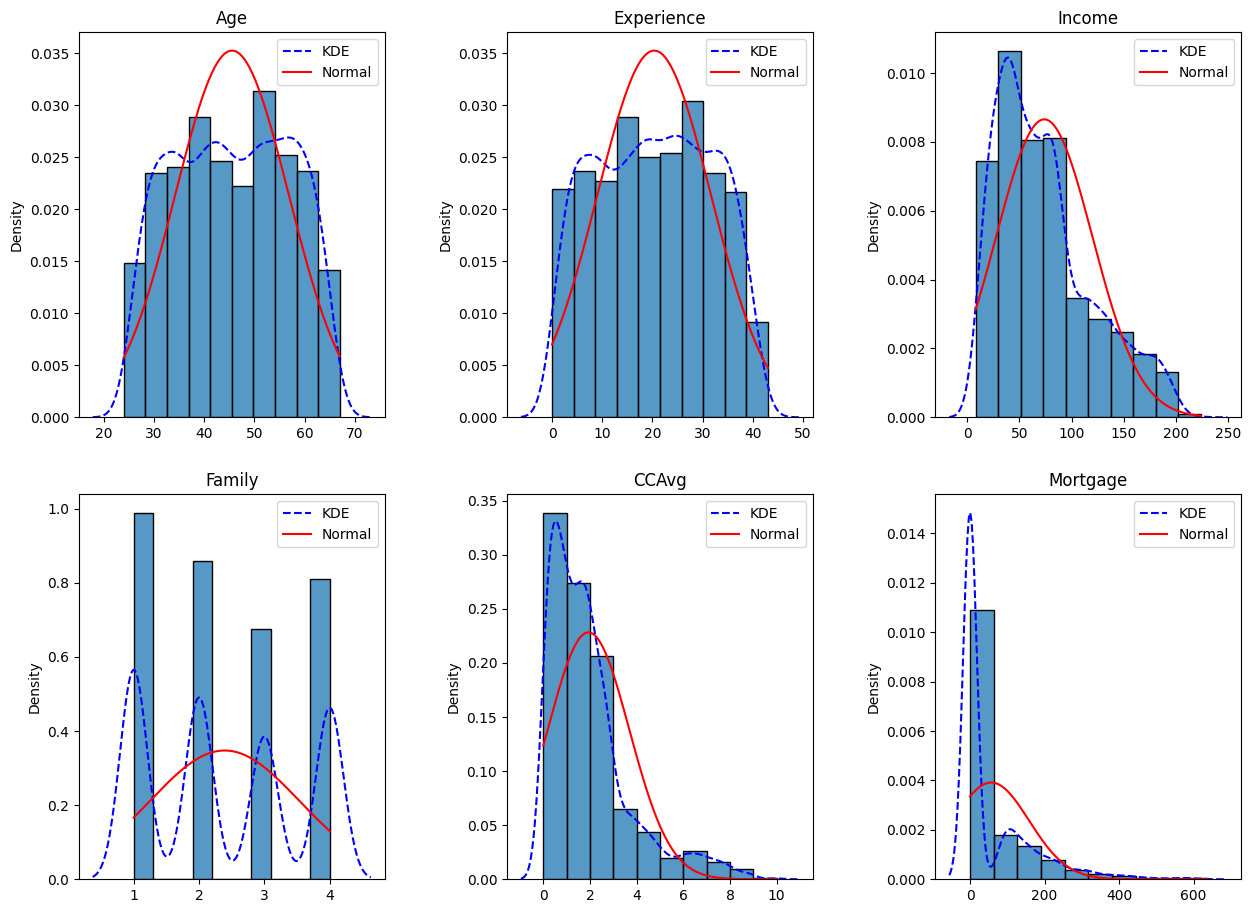

In [ ]:
fig, axes = plt.subplots(2,3, figsize=(15,11))
plt.subplots_adjust(wspace=0.4)
axes = axes.ravel()
for col, ax in zip(loan_df[num_cols], axes):
  sns.histplot(x=loan_df[col], ax=ax, bins=10, stat='density')
  sns.kdeplot(x=loan_df[col], ax=ax, linestyle='dashed', color='blue', label='KDE')

  x = np.linspace(loan_df[col].min(), loan_df[col].max(), 1000)
  normal_ref = norm.pdf(x, loan_df[col].mean(), loan_df[col].std())
  ax.plot(x, normal_ref, color='red', label = 'Normal')

  ax.set(title=f'{col}', xlabel=None)
  ax.legend()

En el caso de Mortgage, se puede apreciar claramente la presencia del sesgo, dado que la mediana se encuentra en 0 mientras que la media, representada por el triángulo verde, se desplaza hacia la derecha. En contraste, variables como Age, que presentan una distribución aproximadamente simétrica, muestran que ambas medidas de tendencia central se ubican en una posición similar.

En conclusión, cuando la mediana y la media se encuentran alejadas entre sí, se puede afirmar que la distribución (sesgo) presenta asimetría. Por el contrario, cuando ambas medidas se encuentran próximas, la distribución (sesgo) es aproximadamente simétrica.

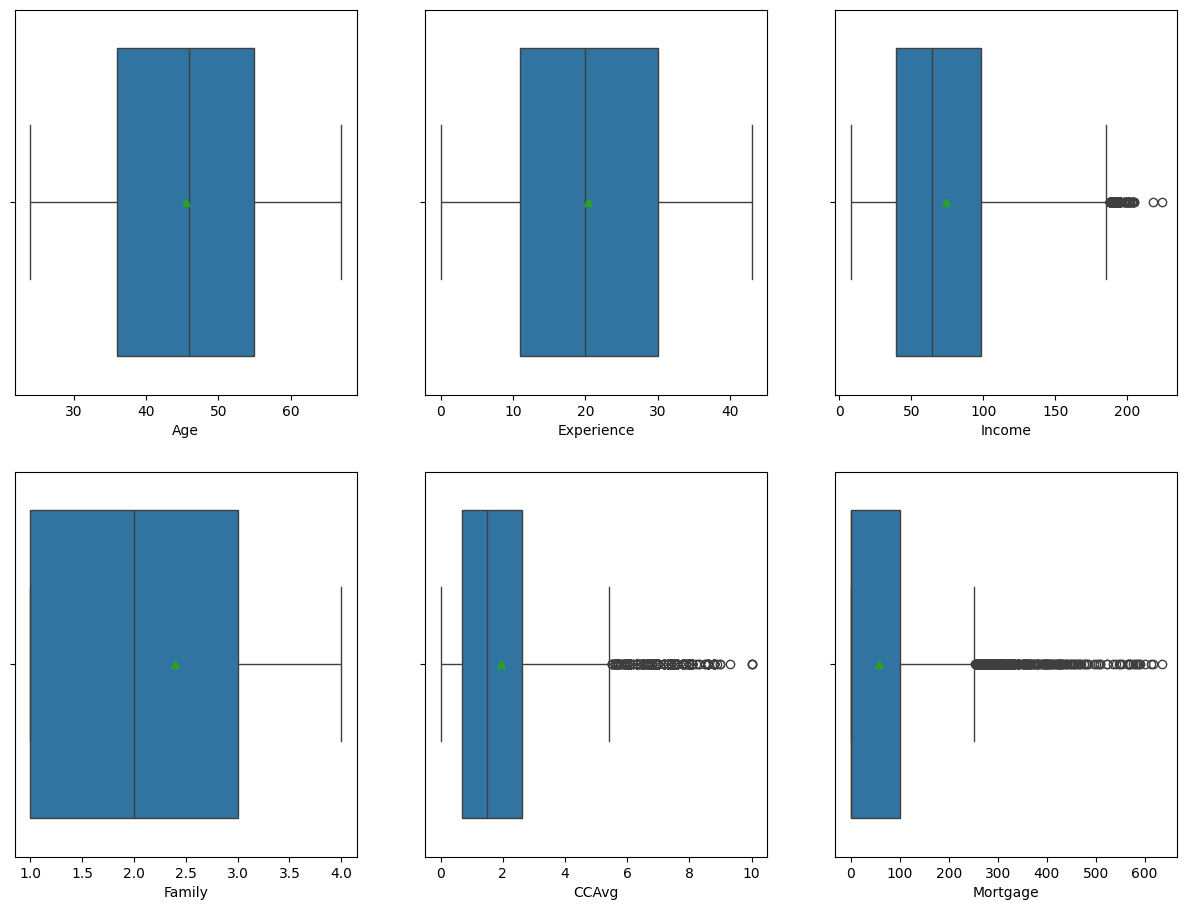

In [ ]:
fig, axes = plt.subplots(2,3, figsize=(15,11))
axes = axes.ravel()
for col, ax in zip(loan_df[num_cols], axes):
  sns.boxplot(x=loan_df[col], ax=ax, showmeans=True) # ---> Seaborn
  ax.set(xlabel=f'{col}')

8. Obtén las estadísticas descriptivas de las variables categóricas.
* Genera un gráfico de barras para cada variable. En las de alta cardinalidad, sólo incluye los 10 valores más relevantes.

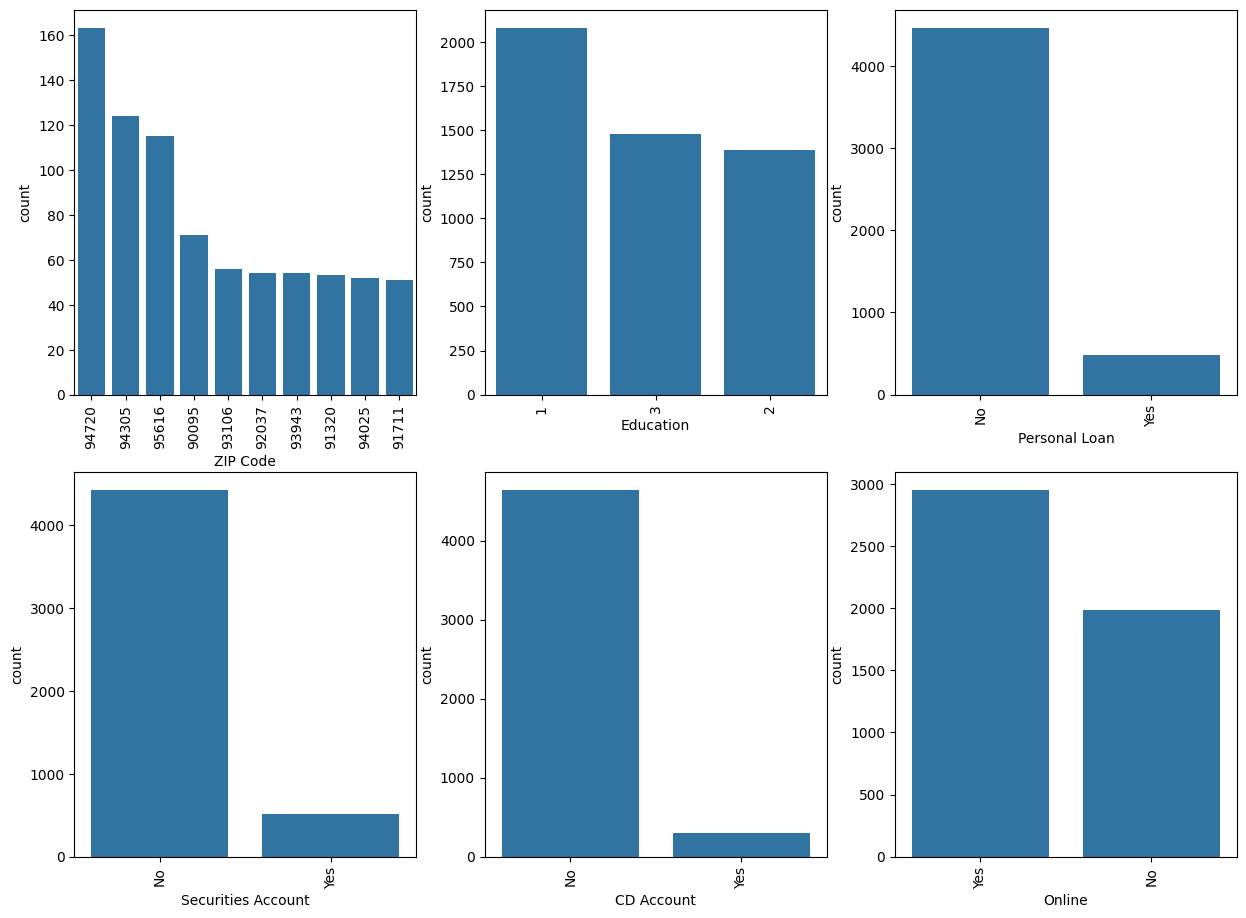

In [ ]:
fig, axes = plt.subplots(2,3, figsize=(15,11))
axes = axes.ravel()
for col, ax in zip(loan_df[cat_cols], axes):
  sns.countplot(x=loan_df[col], ax=ax, order=loan_df[col].value_counts().index[:10])
  ax.tick_params(axis='x',rotation=90)

# Análisis exploratorio de datos (bivariado)

9. Obtén la matriz de gráficos de dispersión (*scatter matrix*) de todas las variables numéricas.
* Observa las relaciones entre las variables, selecciona un par representativo y describe los patrones o tendencias que sean evidentes.
* Para cuantificar la fuerza y dirección de las relaciones observadas, genera un mapa de calor con los valores de correlación de *Pearson*. ¿El valor numérico obtenido del par seleccionado se corresponde con lo esperado?



---


Se observa que Age y Experience están totalmente relacionadas; únicamente con la gráfica podemos determinar que existe una correlación positiva entre ambas, sin embargo, para conocer si esta es perfecta o fuerte, es necesario calcular el coeficiente de Pearson. Por lo tanto, es fácil determinar que a mayor edad, mayor será la experiencia.

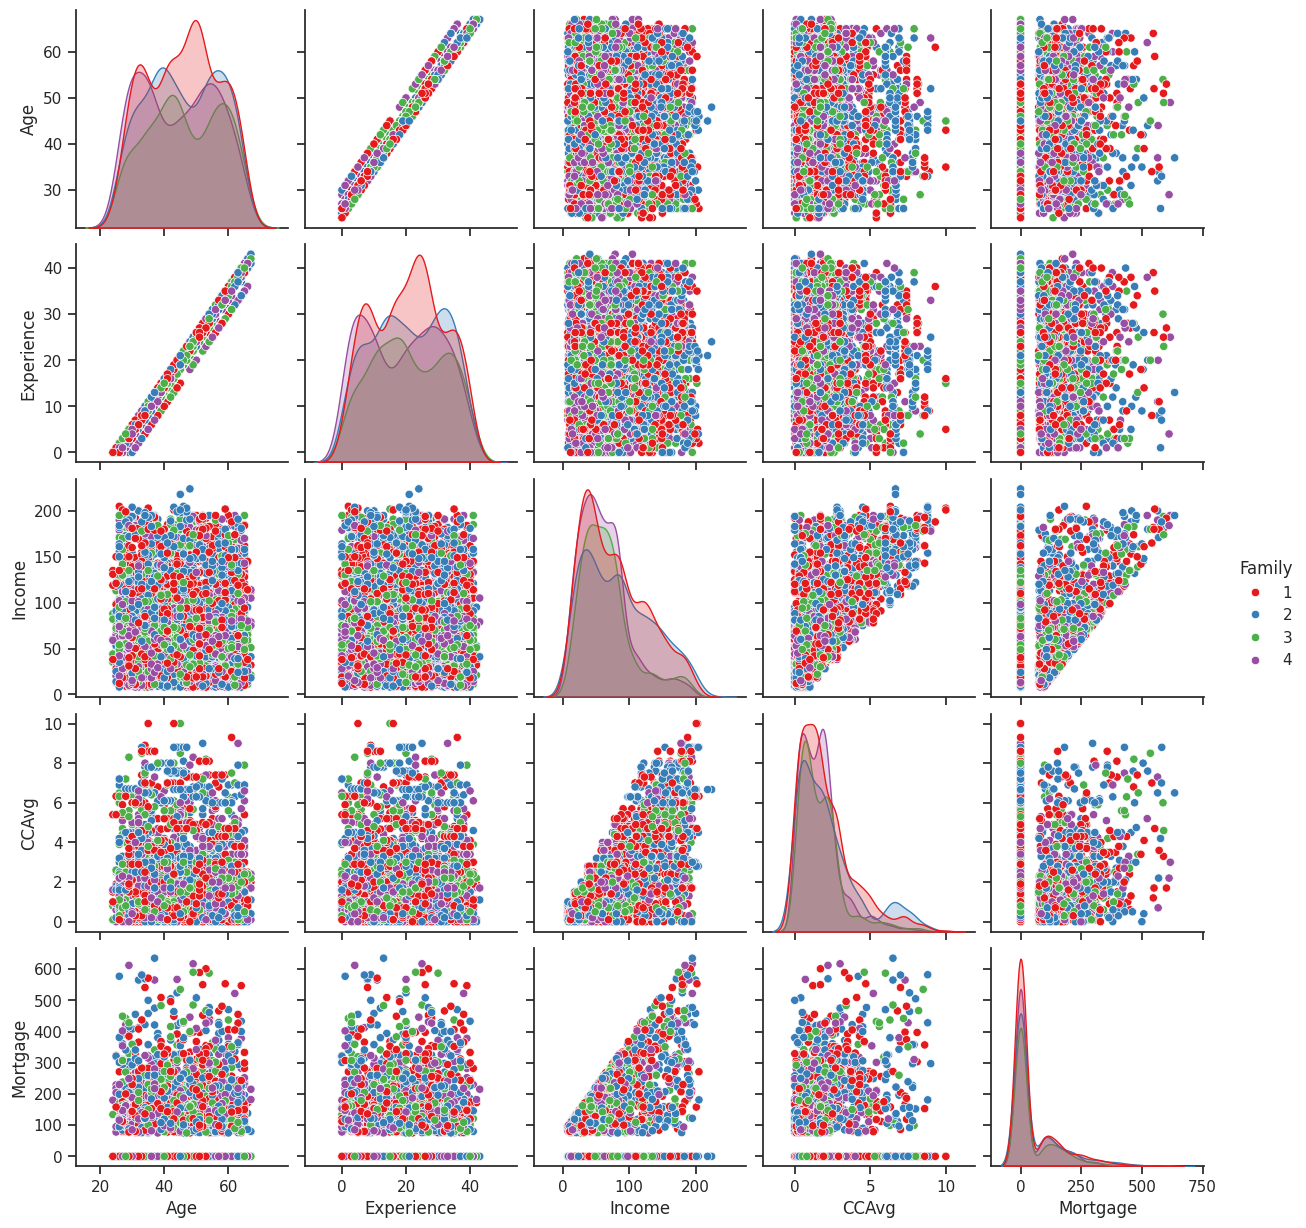

In [ ]:
sns.set(style="ticks", color_codes=True)
sns.pairplot(loan_df, vars=['Age','Experience','Income','CCAvg','Mortgage'], hue="Family", palette="Set1")

plt.show()

Con este mapa de calor se corrobora que Age y Experience están altamente correlacionadas.

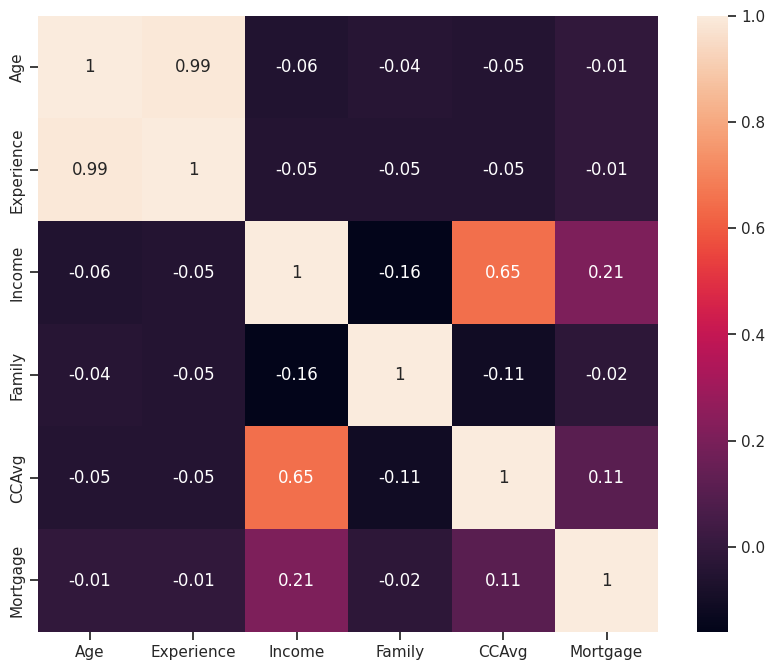

In [ ]:
plt.figure(figsize=(10, 8))
#sns.heatmap(loan_df[num_cols].corr(), annot=True, cmap='coolwarm')
sns.heatmap(round(loan_df.corr(numeric_only=True),2),annot=True)
plt.show()

10. Realiza un análisis de todas las variables del dataset con respecto a la variable de salida `Personal Loan`.
* Variables numéricas: Genera box plots para comparar la distribución de cada variable según los valores de `Personal Loan`.
* Variables categóricas (sin considerar `ZIP Code`): Genera gráficos de barras apiladas que muestren la distribución relativa de `Personal Loan` dentro de cada categoría de la variable.
* Para cada grupo de variables (numéricas y categóricas), comenta al menos un hallazgo o patrón relevante observado en los gráficos generados.


De manera general, se puede observar que las personas con mayores ingresos tienden a aceptar un préstamo. Asimismo, contar con 2 o más miembros en la familia parece influir de igual manera en dicha decisión.

Por lo tanto, las personas con ingresos elevados y 2 o más miembros en la familia tienden a aceptar un préstamo, ya sea por la facilidad para pagarlo o por la necesidad de mantener a más personas.

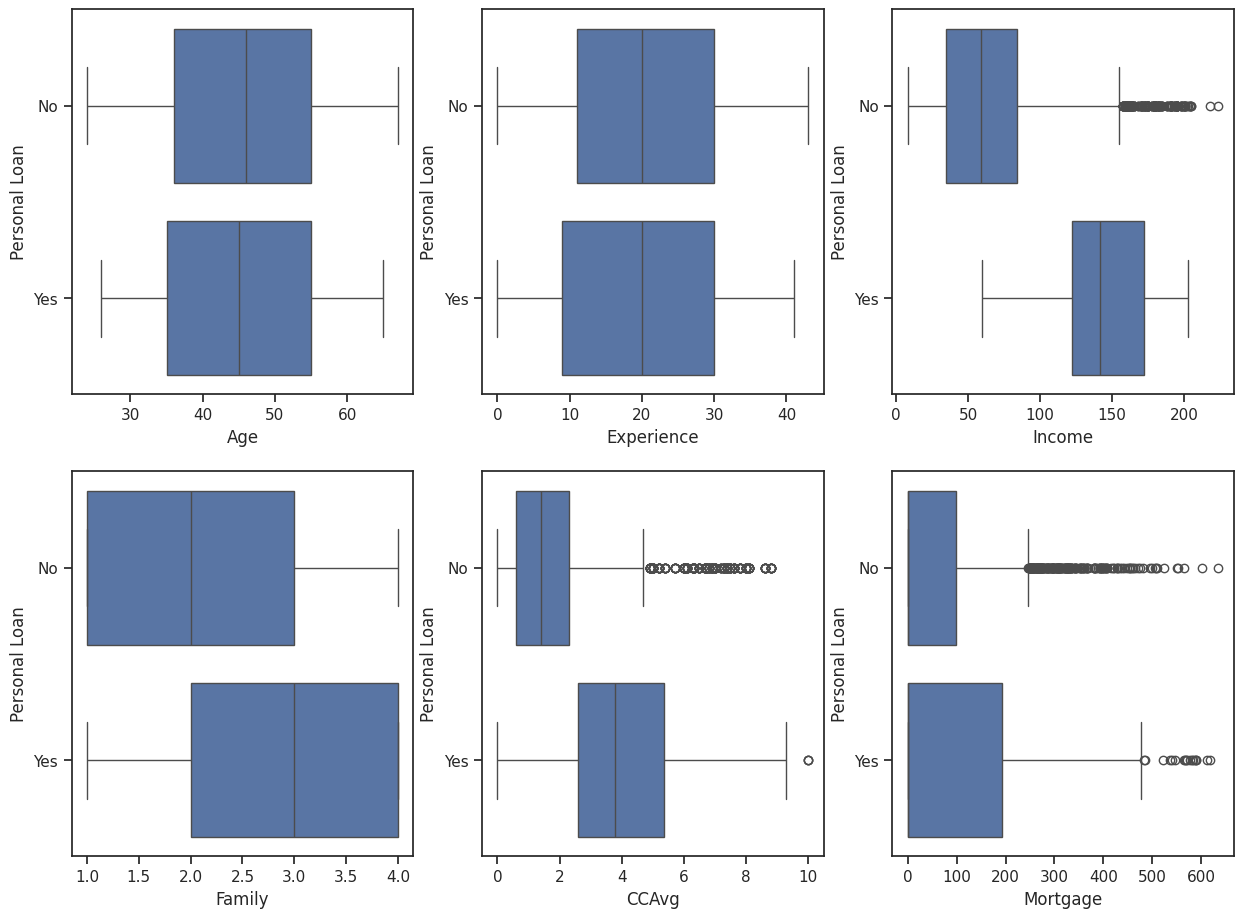

In [ ]:
fig, axes = plt.subplots(2,3, figsize=(15,11))
axes = axes.ravel()
for col, ax in zip(loan_df[num_cols], axes):
  sns.boxplot(x=loan_df[col], y=loan_df['Personal Loan'], ax=ax) # ---> Seaborn
  ax.set(xlabel=f'{col}')


Analizando las variables categóricas, se puede observar que muy pocas personas aceptaron un préstamo personal. Únicamente quienes cuentan con una cuenta CD Account presentan una proporción más equilibrada de aceptación. Asimismo, las personas con un nivel de educación más alto tienen mayor tendencia a aceptar un crédito personal, aunque la proporción sigue siendo baja.

Por lo tanto, las personas que cuentan con una CD Account tienden a aceptar un préstamo con mayor frecuencia. Esto puede deberse a que los intereses generados por su CD Account son suficientes para sostener el costo de un préstamo.

In [ ]:
cat_cols.pop(cat_cols.index('ZIP Code'))

'ZIP Code'

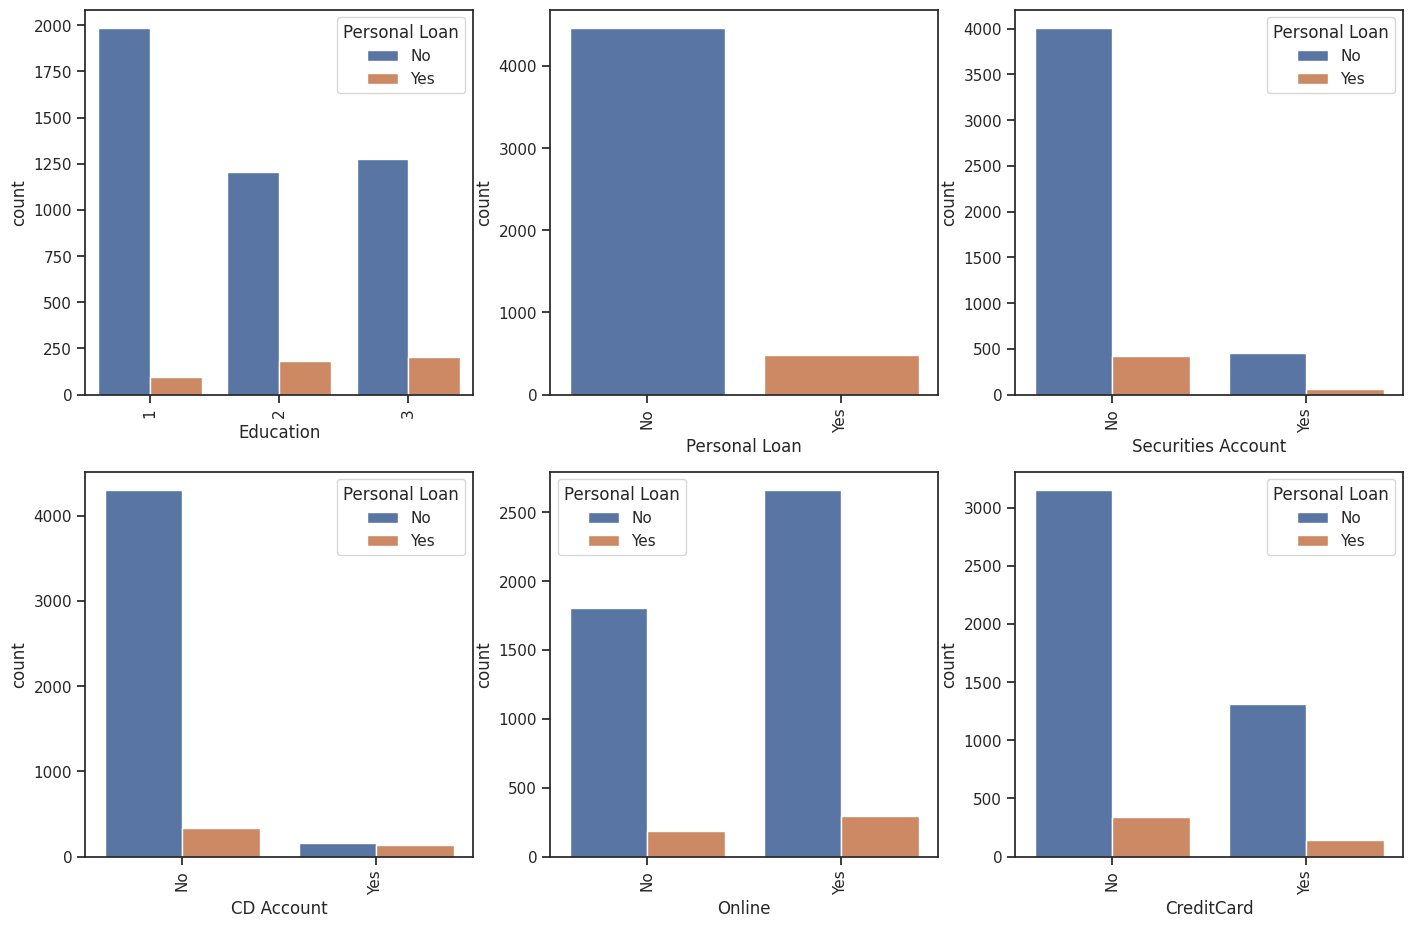

In [ ]:
fig, axes = plt.subplots(2,3, figsize=(17,11))
axes = axes.ravel()
for col, ax in zip(loan_df[cat_cols], axes):
  sns.countplot(x=loan_df[col],hue=loan_df['Personal Loan'], ax=ax)
  ax.tick_params(axis='x',rotation=90)

---

**Declaración de uso de IA**
*   Anthropic. (2026)  *Claude (claude-sonnet-4-6)* [Modelo de lenguaje grande],
utilizado para generación de código y depuración. https://claude.ai
---